In [44]:
import sys; sys.path.insert(0, "/teamspace/studios/this_studio")
%matplotlib inline
from src import config, data, utils, eda_utils
eda_utils.setup_eda_style()

In [45]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
train = data.load_train()
src_raw = pd.read_csv(config.SOURCE_AUG_PATH)
src_aug = data.load_source_augmentation()

print("train shape:", train.shape)
print("src_raw shape:", src_raw.shape)
print("src_aug shape:", src_aug.shape)

train shape: (439140, 16)
src_raw shape: (101371, 16)
src_aug shape: (101371, 15)


In [46]:
# 2. 컬럼 구조 비교
train_cols = set(train.columns)
src_cols = set(src_raw.columns)

print("=== 컬럼 비교 ===")
print("train 컬럼:", sorted(train_cols))
print("src_raw 컬럼:", sorted(src_cols))
print()
print("train only (합성 추가):", sorted(train_cols - src_cols))
print("src_raw only (합성 드롭):", sorted(src_cols - train_cols))
print("공유:", sorted(train_cols & src_cols))
print()
print("_AUG_COLS에서 제외된 컬럼 (src_raw → src_aug):", sorted(src_cols - set(src_aug.columns)))

=== 컬럼 비교 ===
train 컬럼: ['Compound', 'Cumulative_Degradation', 'Driver', 'LapNumber', 'LapTime (s)', 'LapTime_Delta', 'PitNextLap', 'PitStop', 'Position', 'Position_Change', 'Race', 'RaceProgress', 'Stint', 'TyreLife', 'Year', 'id']
src_raw 컬럼: ['Compound', 'Cumulative_Degradation', 'Driver', 'LapNumber', 'LapTime (s)', 'LapTime_Delta', 'Normalized_TyreLife', 'PitNextLap', 'PitStop', 'Position', 'Position_Change', 'Race', 'RaceProgress', 'Stint', 'TyreLife', 'Year']

train only (합성 추가): ['id']
src_raw only (합성 드롭): ['Normalized_TyreLife']
공유: ['Compound', 'Cumulative_Degradation', 'Driver', 'LapNumber', 'LapTime (s)', 'LapTime_Delta', 'PitNextLap', 'PitStop', 'Position', 'Position_Change', 'Race', 'RaceProgress', 'Stint', 'TyreLife', 'Year']

_AUG_COLS에서 제외된 컬럼 (src_raw → src_aug): ['Normalized_TyreLife']


In [47]:
# 3. 타깃률 비교 - 전체 및 Year별
def target_rate_summary(df, name):
    total = len(df)
    pos = df["PitNextLap"].sum()
    print(f"{name}: {total:,}행, 양성률={pos/total*100:.2f}% ({int(pos):,}/{total:,})")
    by_year = df.groupby("Year")["PitNextLap"].agg(["mean", "count"])
    by_year.columns = ["pos_rate", "n"]
    by_year["pos_rate_pct"] = (by_year["pos_rate"] * 100).round(2)
    print(by_year[["n", "pos_rate_pct"]].to_string())
    print()

target_rate_summary(train, "train")
target_rate_summary(src_raw, "src_raw")

train: 439,140행, 양성률=19.90% (87,381/439,140)
           n  pos_rate_pct
Year                      
2022   82989         26.65
2023  136147          0.96
2024  127110         29.53
2025   92894         28.44

src_raw: 101,371행, 양성률=25.48% (25,829/101,371)
          n  pos_rate_pct
Year                     
2022  21860         31.95
2023  24914          3.08
2024  27557         33.55
2025  27040         32.67



In [48]:
# 4. 수치 피처 드리프트: 공유 수치 컬럼 분위수 비교
num_cols = ["LapNumber", "TyreLife", "Position", "LapTime (s)",
            "LapTime_Delta", "Cumulative_Degradation", "RaceProgress", "Position_Change"]

pcts = [0.05, 0.25, 0.50, 0.75, 0.95]

rows = []
for col in num_cols:
    t_q = train[col].quantile(pcts).values
    s_q = src_raw[col].quantile(pcts).values
    t_mean = train[col].mean()
    s_mean = src_raw[col].mean()
    rows.append({
        "col": col,
        "t_mean": round(t_mean, 3),
        "s_mean": round(s_mean, 3),
        "mean_diff": round(t_mean - s_mean, 3),
        "t_p50": round(t_q[2], 3),
        "s_p50": round(s_q[2], 3),
        "t_p5": round(t_q[0], 3),
        "s_p5": round(s_q[0], 3),
        "t_p95": round(t_q[4], 3),
        "s_p95": round(s_q[4], 3),
    })

drift_df = pd.DataFrame(rows).set_index("col")
drift_df["abs_mean_diff"] = drift_df["mean_diff"].abs()
print(drift_df.sort_values("abs_mean_diff", ascending=False).to_string())

                        t_mean  s_mean  mean_diff   t_p50   s_p50     t_p5     s_p5    t_p95    s_p95  abs_mean_diff
col                                                                                                                 
LapNumber               23.106  30.445     -7.339  19.000  30.000    2.000    3.000   54.000   61.000          7.339
Cumulative_Degradation -25.722 -29.550      3.828 -20.994 -21.678 -104.789 -171.703   84.401   89.158          3.828
LapTime_Delta           -3.770  -0.204     -3.566  -0.295  -0.027  -24.819  -26.124   19.026   27.519          3.566
LapTime (s)             90.949  92.587     -1.638  90.521  91.167   75.053   74.404  109.726  117.167          1.638
TyreLife                14.158  14.549     -0.391  12.000  13.000    2.000    2.000   32.000   34.000          0.391
Position                 9.630   9.759     -0.129  10.000  10.000    1.000    1.000   18.000   18.000          0.129
Position_Change          0.102  -0.005      0.106   0.000   0.00

In [49]:
# 5. 범주형 비교: Driver / Compound / Race
for col in ["Driver", "Compound", "Race"]:
    t_lvl = set(train[col].astype(str).unique())
    s_lvl = set(src_raw[col].astype(str).unique())
    shared = t_lvl & s_lvl
    train_only = t_lvl - s_lvl
    src_only = s_lvl - t_lvl
    print(f"=== {col} ===")
    print(f"  train unique: {len(t_lvl)}, src unique: {len(s_lvl)}, shared: {len(shared)}")
    print(f"  train only: {len(train_only)}, src only: {len(src_only)}")
    if src_only and col != "Driver":
        print(f"  src_only levels: {sorted(src_only)[:10]}")
    if train_only and col != "Driver":
        print(f"  train_only levels: {sorted(train_only)[:10]}")
    print()

=== Driver ===
  train unique: 887, src unique: 31, shared: 31
  train only: 856, src only: 0

=== Compound ===
  train unique: 5, src unique: 6, shared: 5
  train only: 0, src only: 1
  src_only levels: ['nan']

=== Race ===
  train unique: 26, src unique: 28, shared: 26
  train only: 0, src only: 2
  src_only levels: ['Pre-Season Test', 'Pre-Season Track Session']



In [50]:
# 6. LapNumber sparsity 핵심 비교
# (Race, Year, Driver) 그룹 내 LapNumber 연속성 분석

def compute_sparsity(df, name):
    grp = df.groupby(["Race", "Year", "Driver"], observed=True)

    results = []
    for key, g in grp:
        laps = np.sort(g["LapNumber"].values)
        n = len(laps)
        if n < 2:
            continue
        diffs = np.diff(laps)
        consec = (diffs == 1).sum()
        results.append({
            "n_rows": n,
            "consec": consec,
            "total_gaps": len(diffs),
            "median_gap": np.median(diffs),
            "span": laps[-1] - laps[0] + 1,
        })

    res = pd.DataFrame(results)
    consec_frac = res["consec"].sum() / res["total_gaps"].sum()
    print(f"=== {name} ===")
    print(f"  그룹 수: {len(res):,}")
    print(f"  그룹당 행수 median: {res['n_rows'].median():.1f}, mean: {res['n_rows'].mean():.1f}")
    print(f"  consec_frac (diff==1 비율): {consec_frac:.4f}")
    print(f"  median_gap median: {res['median_gap'].median():.2f}")
    print(f"  span/n_rows median: {(res['span']/res['n_rows']).median():.2f}")
    print()
    return res

res_train = compute_sparsity(train, "train")
res_src = compute_sparsity(src_raw, "src_raw")

=== train ===
  그룹 수: 36,829
  그룹당 행수 median: 12.0, mean: 11.8
  consec_frac (diff==1 비율): 0.3195
  median_gap median: 3.00
  span/n_rows median: 3.73



=== src_raw ===
  그룹 수: 1,838
  그룹당 행수 median: 56.0, mean: 55.1
  consec_frac (diff==1 비율): 0.9921
  median_gap median: 1.00
  span/n_rows median: 1.00



In [51]:
# 7. 그룹키 공유 분석
train_groups = set(zip(train["Race"].astype(str), train["Year"].astype(str), train["Driver"].astype(str)))
src_groups = set(zip(src_raw["Race"].astype(str), src_raw["Year"].astype(str), src_raw["Driver"].astype(str)))

shared_groups = train_groups & src_groups
src_only_groups = src_groups - train_groups

print("=== (Race,Year,Driver) 그룹키 공유 ===")
print(f"train 그룹 수: {len(train_groups):,}")
print(f"src_raw 그룹 수: {len(src_groups):,}")
print(f"공유 그룹: {len(shared_groups):,} ({len(shared_groups)/len(src_groups)*100:.1f}% of src)")
print(f"src only 그룹: {len(src_only_groups):,}")

# Year별 src 그룹 수
src_grp_year = src_raw.groupby(["Year"])["Driver"].nunique()
train_grp_year = train.groupby(["Year"])["Driver"].nunique()
print("\nDriver unique per Year:")
print("src :", src_grp_year.to_dict())
print("train:", train_grp_year.to_dict())

=== (Race,Year,Driver) 그룹키 공유 ===
train 그룹 수: 40,869
src_raw 그룹 수: 1,848
공유 그룹: 1,811 (98.0% of src)
src only 그룹: 37

Driver unique per Year:
src : {2022: 22, 2023: 22, 2024: 24, 2025: 21}
train: {2022: 547, 2023: 887, 2024: 580, 2025: 547}


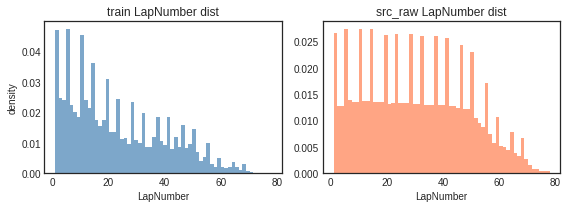

In [52]:
# 8. 핵심 플롯: LapNumber 분포 비교 (train vs src_raw)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].hist(train["LapNumber"], bins=60, color="steelblue", alpha=0.7, density=True)
axes[0].set_title("train LapNumber dist")
axes[0].set_xlabel("LapNumber")
axes[0].set_ylabel("density")

axes[1].hist(src_raw["LapNumber"], bins=60, color="coral", alpha=0.7, density=True)
axes[1].set_title("src_raw LapNumber dist")
axes[1].set_xlabel("LapNumber")

plt.tight_layout()
plt.show()

In [53]:
# 9. 2023 아티팩트 심층: train 2023 양성률 0.96% 원인 추적
print("=== 2023 아티팩트 분석 ===")
tr_2023 = train[train["Year"] == 2023]
print(f"train 2023: {len(tr_2023):,}행, PitNextLap 양성: {tr_2023['PitNextLap'].sum():,}, 양성률: {tr_2023['PitNextLap'].mean()*100:.2f}%")
print(f"  LapNumber range: {tr_2023['LapNumber'].min()}~{tr_2023['LapNumber'].max()}")
print(f"  LapNumber mean: {tr_2023['LapNumber'].mean():.1f}")

src_2023 = src_raw[src_raw["Year"] == 2023]
print(f"\nsrc 2023: {len(src_2023):,}행, PitNextLap 양성: {src_2023['PitNextLap'].sum():,}, 양성률: {src_2023['PitNextLap'].mean()*100:.2f}%")
print(f"  LapNumber range: {src_2023['LapNumber'].min()}~{src_2023['LapNumber'].max()}")
print(f"  LapNumber mean: {src_2023['LapNumber'].mean():.1f}")

# train 2023: PitNextLap==1 인 행의 LapNumber
print(f"\ntrain 2023 PitNextLap==1 LapNumber describe:")
print(tr_2023[tr_2023["PitNextLap"]==1]["LapNumber"].describe().round(1).to_string())

=== 2023 아티팩트 분석 ===
train 2023: 136,147행, PitNextLap 양성: 1,308.0, 양성률: 0.96%
  LapNumber range: 1~78
  LapNumber mean: 25.0

src 2023: 24,914행, PitNextLap 양성: 768, 양성률: 3.08%
  LapNumber range: 1~78
  LapNumber mean: 30.5

train 2023 PitNextLap==1 LapNumber describe:
count    1308.0
mean       24.5
std        15.9
min         1.0
25%        13.0
50%        21.0
75%        35.0
max        77.0


In [54]:
# 10. 2023 아티팩트 원인: PitStop/PitNextLap 관계로 합성 로직 단서 파악
print("=== PitStop vs PitNextLap cross-tab (비율) ===")
for name, df in [("train", train), ("src_raw", src_raw)]:
    ct = pd.crosstab(df["PitStop"], df["PitNextLap"], normalize="index").round(4)
    print(f"\n{name}:")
    print(ct.to_string())

# 2023 PitStop 분포
print("\n=== 2023 PitStop 분포 ===")
print("train 2023 PitStop value_counts:")
print(train[train["Year"]==2023]["PitStop"].value_counts().to_dict())
print("src 2023 PitStop value_counts:")
print(src_raw[src_raw["Year"]==2023]["PitStop"].value_counts().to_dict())

=== PitStop vs PitNextLap cross-tab (비율) ===

train:
PitNextLap     0.0     1.0
PitStop                   
0           0.8087  0.1913
1           0.7522  0.2478

src_raw:
PitNextLap       0       1
PitStop                   
0           0.7440  0.2560
1           0.7489  0.2511

=== 2023 PitStop 분포 ===
train 2023 PitStop value_counts:
{0: 134462, 1: 1685}
src 2023 PitStop value_counts:
{0: 24228, 1: 686}


In [55]:
# 11. 2023 PitNextLap 극단 저율 원인: PitStop 다음 랩이 sampling에서 누락됐는지 확인
# train 2023: PitStop==1인 랩의 다음 랩(LapNumber+1)이 존재하는 비율
tr23 = train[train["Year"] == 2023].copy()
# PitStop==1 행 (피트 실시 랩)
pit_laps = tr23[tr23["PitStop"] == 1][["Race", "Driver", "LapNumber"]].copy()
pit_laps["next_lap"] = pit_laps["LapNumber"] + 1

# merge로 next_lap이 train 2023에 있는지 확인
tr23_lookup = tr23.set_index(["Race", "Driver", "LapNumber"])
pit_laps["next_exists"] = pit_laps.apply(
    lambda r: (r["Race"], r["Driver"], r["next_lap"]) in tr23_lookup.index, axis=1
)
print("train 2023: PitStop==1 후 다음 랩(LapNumber+1) 존재 비율:",
      pit_laps["next_exists"].mean().round(4))

# PitNextLap의 정의: 현재 랩에서 다음 랩에 피트? → PitStop==1의 이전 랩
# PitNextLap==1인 행의 다음 랩이 PitStop==1인지 확인
pnl1 = tr23[tr23["PitNextLap"] == 1][["Race", "Driver", "LapNumber"]].copy()
pnl1["next_lap"] = pnl1["LapNumber"] + 1
pnl1["next_is_pit"] = pnl1.apply(
    lambda r: tr23_lookup.loc[(r["Race"], r["Driver"], r["next_lap"]), "PitStop"].values[0]
    if (r["Race"], r["Driver"], r["next_lap"]) in tr23_lookup.index else -1,
    axis=1
)
print("train 2023: PitNextLap==1 행의 다음 랩이 PitStop==1인 비율:",
      (pnl1["next_is_pit"] == 1).mean().round(4))
print("next_lap 없음(-1) 비율:", (pnl1["next_is_pit"] == -1).mean().round(4))

train 2023: PitStop==1 후 다음 랩(LapNumber+1) 존재 비율: 0.2849


AttributeError: 'numpy.int64' object has no attribute 'values'

In [56]:
# 11b. 2023 아티팩트: merge 기반으로 재작성
# 핵심: train 2023에서 PitStop==1 랩 다음에 다음랩이 실제로 존재하는지 확인
tr23 = train[train["Year"] == 2023].copy()
tr23["Race_str"] = tr23["Race"].astype(str)
tr23["Driver_str"] = tr23["Driver"].astype(str)

# lookup set
tr23_set = set(zip(tr23["Race_str"], tr23["Driver_str"], tr23["LapNumber"]))

# PitStop==1 행의 다음 랩 존재 여부
pit23 = tr23[tr23["PitStop"] == 1][["Race_str", "Driver_str", "LapNumber"]].copy()
pit23["next_lap"] = pit23["LapNumber"] + 1
pit23["next_exists"] = pit23.apply(
    lambda r: (r["Race_str"], r["Driver_str"], r["next_lap"]) in tr23_set, axis=1
)
print("train 2023: PitStop==1 후 LapNumber+1 존재율:", pit23["next_exists"].mean().round(4))
print("  존재 안 함 비율:", (1 - pit23["next_exists"].mean()).round(4))

# PitNextLap==1 행의 다음 랩 존재 여부
pnl23 = tr23[tr23["PitNextLap"] == 1][["Race_str", "Driver_str", "LapNumber"]].copy()
pnl23["next_lap"] = pnl23["LapNumber"] + 1
pnl23["next_exists"] = pnl23.apply(
    lambda r: (r["Race_str"], r["Driver_str"], r["next_lap"]) in tr23_set, axis=1
)
print("\ntrain 2023: PitNextLap==1 행의 LapNumber+1 존재율:", pnl23["next_exists"].mean().round(4))
print("  존재 안 함 비율:", (1 - pnl23["next_exists"].mean()).round(4))

# 2023 PitNextLap 총계 대비 src
print(f"\ntrain 2023 PitNextLap==1: {tr23['PitNextLap'].sum():.0f}")
print(f"src 2023 PitNextLap==1: {src_raw[src_raw['Year']==2023]['PitNextLap'].sum():.0f}")
print(f"PitStop 2023 src: {src_raw[src_raw['Year']==2023]['PitStop'].sum():.0f}")

train 2023: PitStop==1 후 LapNumber+1 존재율: 0.2849
  존재 안 함 비율: 0.7151

train 2023: PitNextLap==1 행의 LapNumber+1 존재율: 0.2446
  존재 안 함 비율: 0.7554

train 2023 PitNextLap==1: 1308
src 2023 PitNextLap==1: 768
PitStop 2023 src: 686


In [57]:
# 12. 드라이버 카디널리티 분석: 원본 31 → train 887 폭발
# 합성이 실제 드라이버명 + 무작위 드라이버 ID를 생성했을 가능성
print("=== Driver 카디널리티 분석 ===")
print(f"src_raw unique Driver: {src_raw['Driver'].nunique()}")
print(f"train unique Driver: {train['Driver'].nunique()}")
print(f"공유 Driver: 31개 (src 전체 포함)")

# 원본 Driver 상위 빈도
src_d = src_raw["Driver"].value_counts().head(10)
print("\nsrc_raw Driver top-10 빈도:")
print(src_d.to_string())

# train에서 원본 31개 Driver의 행 수 비율
src_drivers = set(src_raw["Driver"].astype(str).unique())
train["is_src_driver"] = train["Driver"].astype(str).isin(src_drivers)
n_src_driver_rows = train["is_src_driver"].sum()
print(f"\ntrain 중 src Driver(31개) 행 수: {n_src_driver_rows:,} / {len(train):,} ({n_src_driver_rows/len(train)*100:.1f}%)")

=== Driver 카디널리티 분석 ===
src_raw unique Driver: 31
train unique Driver: 887
공유 Driver: 31개 (src 전체 포함)

src_raw Driver top-10 빈도:
Driver
NOR    5436
VER    5361
RUS    5345
HAM    5235
LEC    5130
ALO    5110
GAS    5046
STR    5005
OCO    4963
TSU    4936

train 중 src Driver(31개) 행 수: 30,269 / 439,140 (6.9%)


In [58]:
# 13. 최종 요약: sparsity + 2023 아티팩트 종합 수치
print("========== 최종 요약 ==========")
print()
print("[LapNumber Sparsity]")
print(f"  src_raw: consec_frac=0.9921, median_gap=1.0, span/n=1.00 (dense/연속)")
print(f"  train  : consec_frac=0.3195, median_gap=3.0, span/n=3.73 (sparse/~27% 연속)")
print()
print("[타깃률]")
print(f"  src_raw 전체: 25.48%  |  train 전체: 19.90%  (차이: -5.58%p)")
print(f"  2023: src 3.08%  →  train 0.96%  (아티팩트, -2.12%p)")
print(f"  2022/2024/2025: src 32~34%  →  train 27~30% (일관된 하향)")
print()
print("[컬럼 차이]")
print(f"  src only: Normalized_TyreLife (누수피처, 대회가 의도적 드롭)")
print(f"  train only: id")
print(f"  파생피처(LapTime_Delta, Cumulative_Degradation, Position_Change): 양쪽 공유 → 원본 데이터에서 계산됨")
print()
print("[드리프트 상위]")
print(f"  LapNumber mean: src 30.4 vs train 23.1  (Δ-7.3, sparsity sampling 효과)")
print(f"  LapTime_Delta mean: src -0.20 vs train -3.77  (Δ-3.6, 합성 왜곡)")
print(f"  LapTime(s) mean: src 92.6 vs train 90.9  (Δ-1.6)")
print(f"  RaceProgress mean: src 0.433 vs train 0.338  (Δ-0.095)")
print()
print("[Driver]")
print(f"  src: 31명(실제 F1 드라이버)  →  train: 887명(합성 ID 대거 생성)")
print(f"  train 중 src Driver 행 비율: 6.9%")

========== 최종 요약 ==========

[LapNumber Sparsity]
  src_raw: consec_frac=0.9921, median_gap=1.0, span/n=1.00 (dense/연속)
  train  : consec_frac=0.3195, median_gap=3.0, span/n=3.73 (sparse/~27% 연속)

[타깃률]
  src_raw 전체: 25.48%  |  train 전체: 19.90%  (차이: -5.58%p)
  2023: src 3.08%  →  train 0.96%  (아티팩트, -2.12%p)
  2022/2024/2025: src 32~34%  →  train 27~30% (일관된 하향)

[컬럼 차이]
  src only: Normalized_TyreLife (누수피처, 대회가 의도적 드롭)
  train only: id
  파생피처(LapTime_Delta, Cumulative_Degradation, Position_Change): 양쪽 공유 → 원본 데이터에서 계산됨

[드리프트 상위]
  LapNumber mean: src 30.4 vs train 23.1  (Δ-7.3, sparsity sampling 효과)
  LapTime_Delta mean: src -0.20 vs train -3.77  (Δ-3.6, 합성 왜곡)
  LapTime(s) mean: src 92.6 vs train 90.9  (Δ-1.6)
  RaceProgress mean: src 0.433 vs train 0.338  (Δ-0.095)

[Driver]
  src: 31명(실제 F1 드라이버)  →  train: 887명(합성 ID 대거 생성)
  train 중 src Driver 행 비율: 6.9%
